# Multi-year urban green statistics — demonstrator

SATDES Task 1, Subtask 1.6. This notebook is a thin front end over the
`urban_green` package (see `../src/urban_green/`): it does not
reimplement any logic, it just calls the same pipeline the CLI
(`python -m urban_green.cli`) runs, and displays the results inline.

Set `DES_USERNAME` / `DES_PASSWORD` in the environment before running
this notebook for real Digital Earth Sweden access; otherwise it falls
back to the placeholder test credentials.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from IPython.display import Image, display

from urban_green.config import PipelineConfig
from urban_green.pipeline import run

## 1. Configure the run

Point `ROI_PATH` at any vector file covering part of Sweden (Shapefile, GeoPackage, GeoParquet, GeoJSON, ...). Defaults below to the Örebro tätort boundary (`tests/data/tatorter_2023_orebro.parquet`).

This demo run uses the DES test credentials (`testuser` / `secretpassword`) unless `DES_USERNAME`/`DES_PASSWORD` are set in the
environment.

Modify the start and end year (exclusive) for the analysis by changing the range assigned to the `YEARS` variable. 

In [2]:
ROI_PATH = "../tests/data/tatorter_2023_orebro.parquet"
YEARS = list(range(2022, 2026))
OUTPUT_DIR = "./outputs_demo"
REGION_ID_FIELD = None  # set to a column name for per-sub-region statistics

config = PipelineConfig(
    roi_path=ROI_PATH,
    years=YEARS,
    output_dir=OUTPUT_DIR,
    region_id_field=REGION_ID_FIELD,
)

## 2. Preview the ROI

In [3]:
roi_preview = gpd.read_parquet(ROI_PATH) if str(ROI_PATH).endswith(".parquet") else gpd.read_file(ROI_PATH)
roi_preview.explore()

## 3. Run the pipeline

This acquires annual max-NDVI from Digital Earth Sweden for every tile x year, stitches it, thresholds it, computes statistics and the change product, and writes figures.

Under the hood, `run()`:

1. Pulls per-tile, per-year max-NDVI composites from DES (or the local `tile_store` cache, if already acquired) and stitches them into one mosaic per year.
2. Fits a Gaussian Mixture Model (2 components) on NDVI values
   pooled across all years and pixels inside the ROI, and sets the
   vegetated/non-vegetated threshold at the intersection of the two
   fitted Gaussians.
3. Classifies each year's mosaic against that threshold, then smooths the result along the year axis (an isolated single-year flip is reclassified to match its neighbouring years).
4. Derives statistics and the loss/gain change-year rasters from the smoothed classification, and writes the figures below.

In [4]:
outputs_dir = run(config)
outputs_dir


acquiring 2022: 100%|##########| 4/4 [00:00<00:00, 13595.80it/s]

acquiring 2023: 100%|##########| 4/4 [00:00<00:00, 29799.67it/s]

acquiring 2024: 100%|##########| 4/4 [00:00<00:00, 32326.04it/s]

acquiring 2025: 100%|##########| 4/4 [00:00<00:00, 32704.12it/s]
/home/sebastian-hafner/projects/satdes/task1/repos/satdes_urban_green_pipeline/src/urban_green/thresholding.py:67: RuntimeWarning: Mean of empty slice
  majority = np.nanmean(win, axis=0) >= 0.5


PosixPath('outputs_demo/outputs')

## 4. Inspect results

### `green_area_statistics.csv`

| Column | Meaning |
|---|---|
| `year` | Calendar year of the composite |
| `green_area_km2` | Vegetated area inside the ROI (pixels classified vegetated × pixel area), after the smoothing |
| `pct_cover` | `green_area_km2` as a percentage of the valid (non-nodata, inside-ROI) area for that year |
| `change_km2` | Net year-on-year change in `green_area_km2` (this year minus last year); `0.0` for the first year |

In [5]:
stats = pd.read_csv(outputs_dir / "green_area_statistics.csv")
stats

,year,green_area_km2,pct_cover,change_km2
0,2022,22.8090,40.566714,0.0000
1,2023,22.8466,40.633587,0.0376
2,2024,23.6954,42.143212,0.8488
3,2025,24.2274,43.089395,0.5320


### `change_statistics.csv`

| Column | Meaning |
|---|---|
| `year` | Calendar year of the transition |
| `loss_km2` | Area whose first vegetated → non-vegetated transition (in the smoothed classification) happened in this year |
| `gain_km2` | Area whose first non-vegetated → vegetated transition happened in this year |

These are gross figures derived from `green_loss_year.tif` / `green_gain_year.tif` (each pixel is only counted once, in the year of its first transition).

In [6]:
change_stats = pd.read_csv(outputs_dir / "change_statistics.csv")
change_stats

,year,loss_km2,gain_km2
0,2023,0.6031,0.6407
1,2024,0.3696,1.2184
2,2025,0.3487,0.8807


### Figures

- **`ndvi_distribution.png`** — kernel density estimate of NDVI values
  pooled across all years and ROI pixels, with the fitted GMM threshold
  (dashed red line) and the "vegetated" side of it shaded green. A
  threshold sitting in the trough between two visually distinct modes is
  a good sign the GMM found a genuine vegetated/non-vegetated split
  rather than an artifact.
- **`green_area_timeseries.png`** — top panel: `green_area_km2` per year
  (the threshold value is overlaid on a secondary axis); bottom panel:
  `change_km2` per year as a bar chart, green for a net increase and red
  for a net decrease.

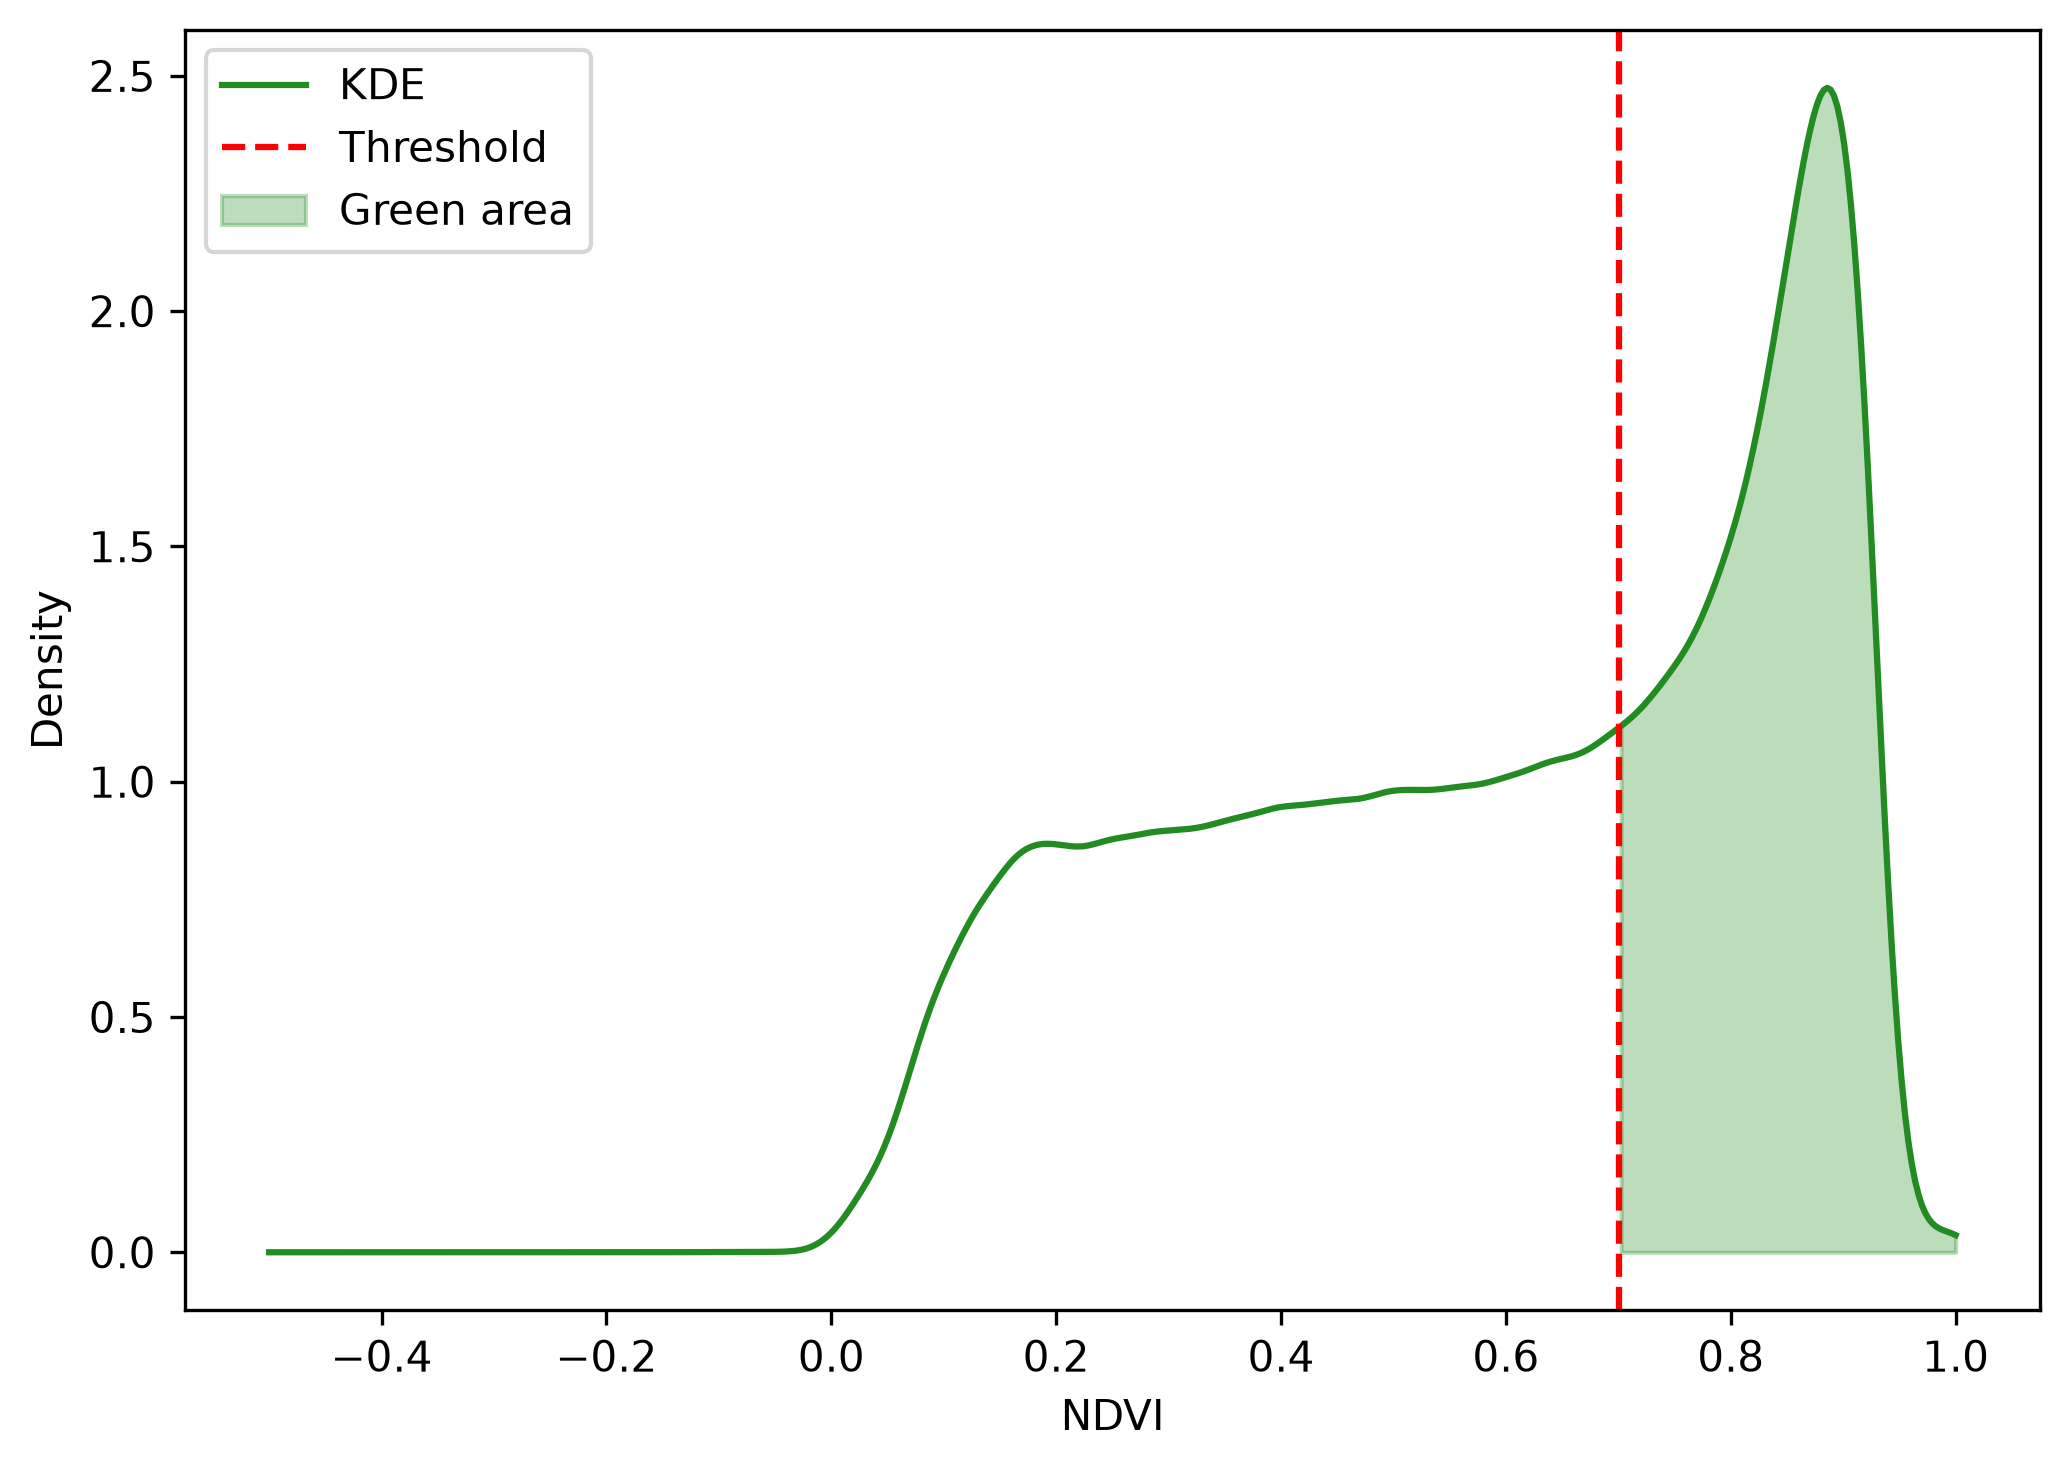

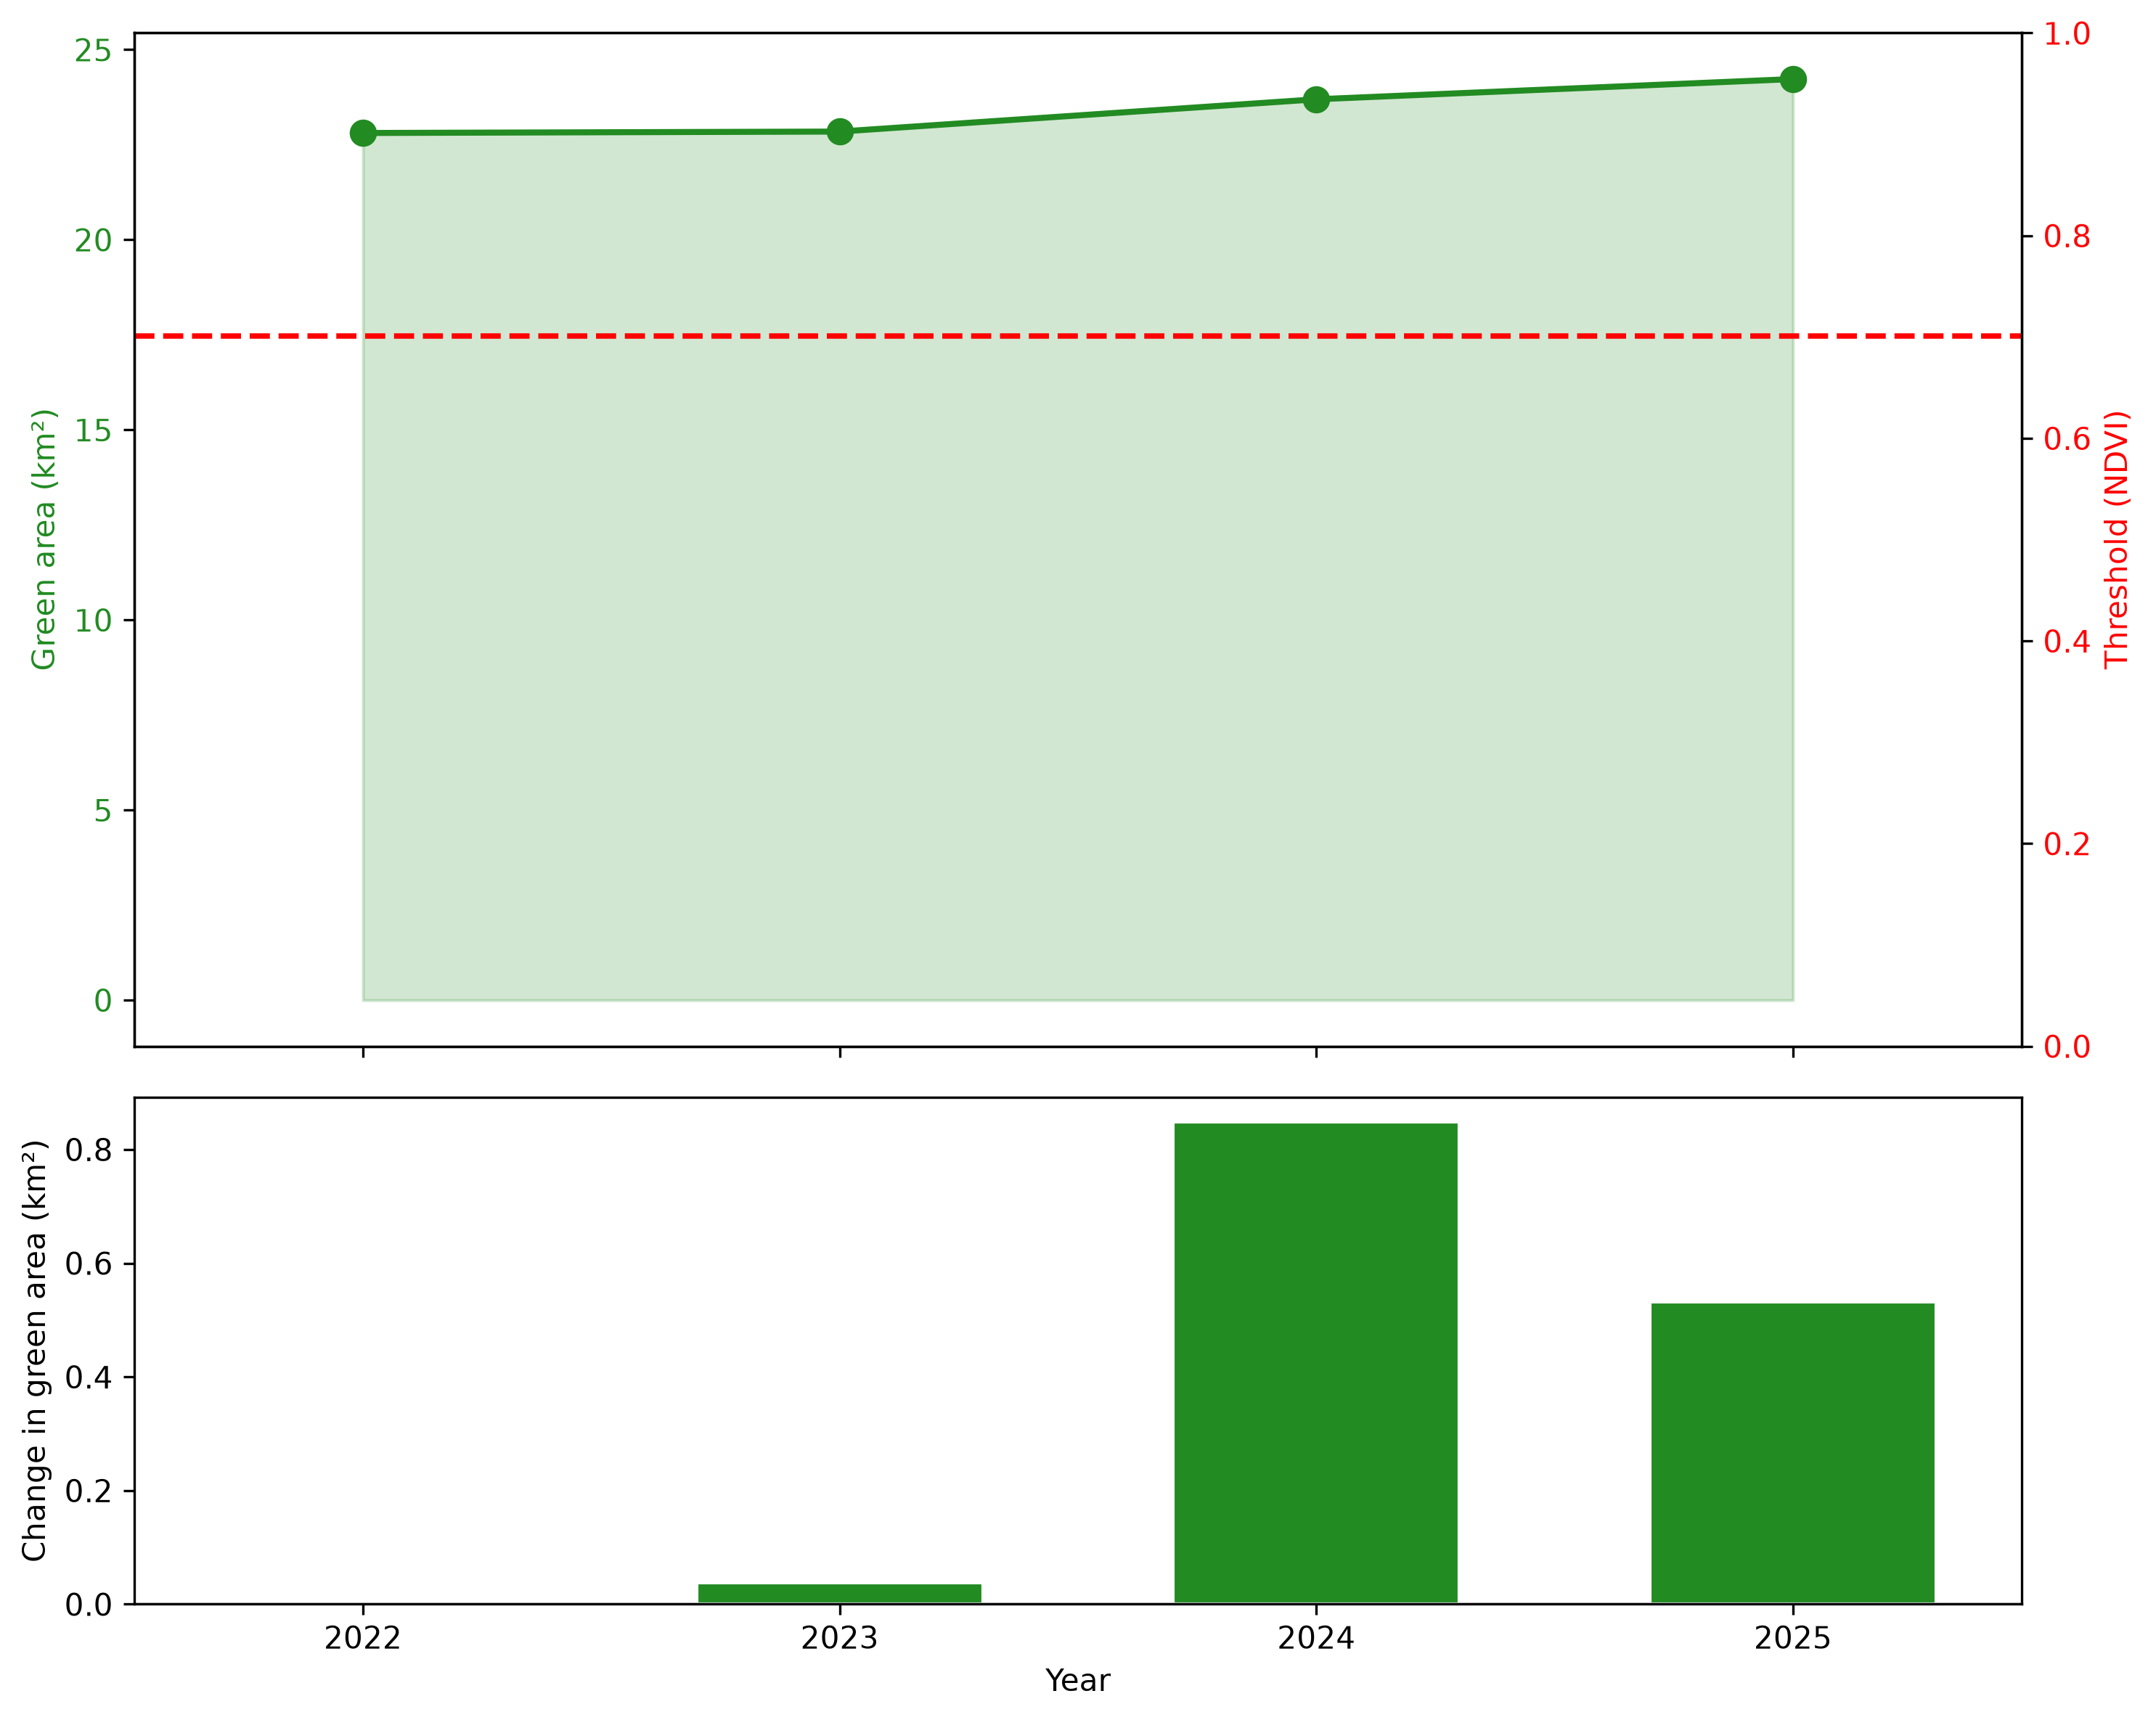

In [7]:
figures_dir = outputs_dir.parent / "figures"
display(Image(filename=str(figures_dir / "ndvi_distribution.png")))
display(Image(filename=str(figures_dir / "green_area_timeseries.png")))

## 4b. Raster outputs

`green_area_statistics.csv` and the figures above summarize the ROI as a
whole, but the pipeline's actual per-pixel products are GeoTIFFs written
to `outputs_dir`: `vegetation_<year>.tif` (binary classification) and
`green_loss_year.tif` / `green_gain_year.tif` (change-year rasters).

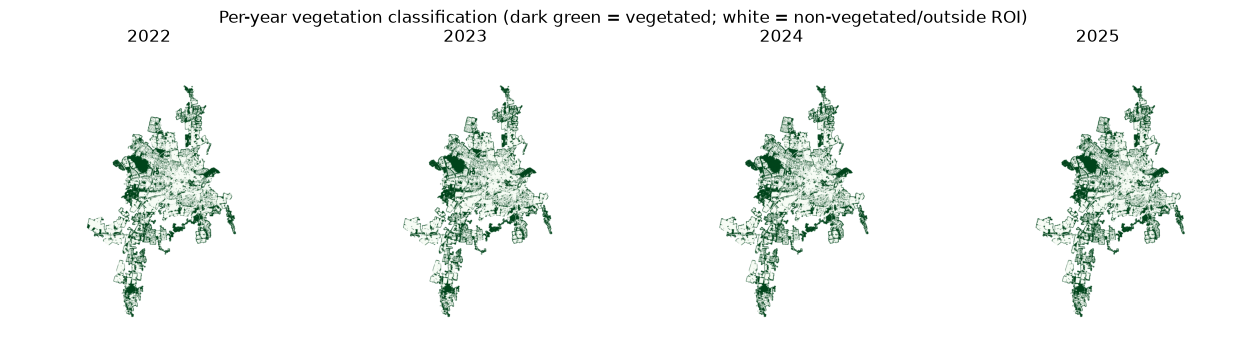

In [8]:
n_years = len(config.years)
fig, axes = plt.subplots(1, n_years, figsize=(3.2 * n_years, 3.4))
for ax, year in zip(axes, config.years):
    with rasterio.open(outputs_dir / f"vegetation_{year}.tif") as src:
        veg = src.read(1).astype(float)
        veg[veg == src.nodata] = np.nan
    ax.imshow(veg, cmap="Greens", vmin=0, vmax=1)
    ax.set_title(str(year))
    ax.axis("off")
fig.suptitle("Per-year vegetation classification (dark green = vegetated; white = non-vegetated/outside ROI)")
fig.tight_layout()
plt.show()

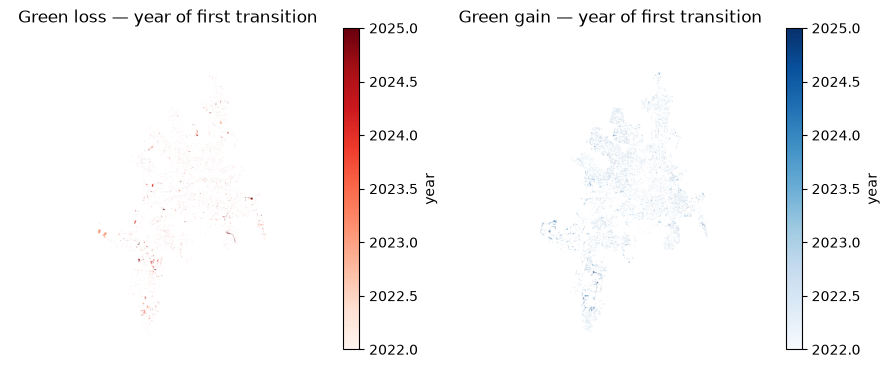

In [9]:
with rasterio.open(outputs_dir / "green_loss_year.tif") as src:
    loss_year = src.read(1).astype(float)
    loss_year[loss_year == src.nodata] = np.nan
with rasterio.open(outputs_dir / "green_gain_year.tif") as src:
    gain_year = src.read(1).astype(float)
    gain_year[gain_year == src.nodata] = np.nan

fig, (ax_loss, ax_gain) = plt.subplots(1, 2, figsize=(9, 4.2))
im_loss = ax_loss.imshow(loss_year, cmap="Reds", vmin=min(config.years), vmax=max(config.years))
ax_loss.set_title("Green loss — year of first transition")
ax_loss.axis("off")
fig.colorbar(im_loss, ax=ax_loss, fraction=0.046, label="year")

im_gain = ax_gain.imshow(gain_year, cmap="Blues", vmin=min(config.years), vmax=max(config.years))
ax_gain.set_title("Green gain — year of first transition")
ax_gain.axis("off")
fig.colorbar(im_gain, ax=ax_gain, fraction=0.046, label="year")
fig.tight_layout()
plt.show()

Blank/white pixels are nodata: outside the ROI for the vegetation
rasters, and "no transition observed" for the loss/gain rasters (pixels
that stayed vegetated or non-vegetated throughout the whole
period). Each loss/gain pixel is colored by the first year that kind
of transition happened.